# BC2410/BC2411 — Resume Shortlisting Optimisation
## Notebook 3: Sensitivity Analysis & Policy Experiments

**Group Project — Prescriptive Analytics: From Data to Decisions**

---

This notebook answers: *"How sensitive are the MILP results to changes in structural parameters?"*

We vary one parameter at a time while holding others fixed, re-solve the MILP for each setting, and measure the impact on key operational metrics. This informs recruiters about the cost of tightening or relaxing constraints.

**Parameters tested:**
1. **Review time budget** (30 → 80 min) — how much time pressure can the recruiter tolerate?
2. **Shortlist size** (3 → 8 candidates) — bigger shortlists vs. recruiter workload
3. **Candidate exposure cap** (1 → 5 jobs) — how much candidate reuse is acceptable?
4. **Quality floor** (0.20 → 0.60) — minimum acceptable match quality

## 1. Setup

Load everything from Notebooks 1 and 2, including the per-job normalised signals and the best configuration from the sweep.

In [3]:
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import gurobipy as gp
    from gurobipy import GRB
    HAS_GUROBI = True
except ImportError:
    HAS_GUROBI = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ── Load data ──
pair_df   = pd.read_csv(DATA_DIR / "pair_features.csv")
resume_df = pd.read_csv(DATA_DIR / "resumes_milp_sample.csv")
job_df    = pd.read_csv(DATA_DIR / "jobs_milp_sample.csv")

for col in ["skill_set", "required_skills"]:
    for df in [resume_df, job_df]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])
if "required_skill_weights" in job_df.columns:
    job_df["required_skill_weights"] = job_df["required_skill_weights"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else {})

# Load best config from NB2
with open(OUT_DIR / "best_config.json") as f:
    best_info = json.load(f)
BEST_CONFIG = best_info["config"]
BASE_BUDGET = best_info.get("budget", 65.0)
BASE_FLOOR  = best_info.get("floor", 0.40)

print(f"Loaded best config: '{best_info['name']}'")
print(f"Base budget: {BASE_BUDGET} min | Base floor: {BASE_FLOOR}")

Loaded best config: 'exp_strict'
Base budget: 65.0 min | Base floor: 0.4


In [5]:
# ── Per-job normalisation (same as NB2) ──
SIGNALS = {
    "tfidf_sim": "pos", "bm25_sim": "pos", "skill_overlap_jaccard": "pos",
    "weighted_required_hit": "pos", "exp_gap": "neg", "degree_gap": "neg", "length_penalty": "neg",
}
norm_df = pair_df.copy()
for signal, direction in SIGNALS.items():
    g = norm_df.groupby("job_id")[signal]
    mins, maxs = g.transform("min"), g.transform("max")
    rng = maxs - mins
    norm_df[f"{signal}_norm"] = np.where(rng > 1e-9, (norm_df[signal] - mins) / rng, 0.5)
    if direction == "neg":
        norm_df[f"{signal}_norm"] = 1.0 - norm_df[f"{signal}_norm"]

# ── Build lookups ──
n_tfidf={}; n_bm25={}; n_skill={}; n_cov={}; n_exp={}; n_deg={}; n_length={}
for _, row in norm_df.iterrows():
    k = (int(row["resume_id"]), int(row["job_id"]))
    n_tfidf[k]=float(row["tfidf_sim_norm"]); n_bm25[k]=float(row["bm25_sim_norm"])
    n_skill[k]=float(row["skill_overlap_jaccard_norm"]); n_cov[k]=float(row["weighted_required_hit_norm"])
    n_exp[k]=float(row["exp_gap_norm"]); n_deg[k]=float(row["degree_gap_norm"])
    n_length[k]=float(row["length_penalty_norm"])

review_time={}; cluster_of={}
for _, r in resume_df.iterrows():
    rid=int(r["resume_id"]); review_time[rid]=float(r["review_minutes_capped"]); cluster_of[rid]=int(r["redundancy_cluster"])

job_req_skills={}; skill_weight={}; skill_has={}
for _, row in job_df.iterrows():
    j=int(row["job_id"]); req=row["required_skills"]; weights=row["required_skill_weights"]
    job_req_skills[j]=set(req)
    for s in req: skill_weight[(j,s)]=float(weights.get(s,1.0))

for _, row in pair_df.iterrows():
    i,j=int(row["resume_id"]),int(row["job_id"])
    if j in job_req_skills:
        r_sk=set(resume_df.loc[resume_df["resume_id"]==i,"skill_set"].iloc[0])
        for s in job_req_skills[j]: skill_has[(i,j,s)]=1 if s in r_sk else 0

cluster_members={}
for rid,cid in cluster_of.items(): cluster_members.setdefault(cid,[]).append(rid)

ALL_RESUMES=sorted(resume_df["resume_id"].unique())
ALL_JOBS=sorted(job_df["job_id"].unique())
ALL_PAIRS=list(n_tfidf.keys())

print(f"Ready: {len(ALL_PAIRS):,} pairs, {len(ALL_JOBS)} jobs, {len(ALL_RESUMES)} resumes")

Ready: 45,000 pairs, 90 jobs, 500 resumes


## 2. Solver & Evaluator (from NB2)

In [7]:
def pair_quality(i, j, w):
    return (w["w_tfidf"]*n_tfidf[(i,j)] + w["w_bm25"]*n_bm25[(i,j)]
          + w["w_skill"]*n_skill[(i,j)] + w["w_coverage"]*n_cov[(i,j)]
          + w["w_exp"]*n_exp[(i,j)] + w["w_deg"]*n_deg[(i,j)]
          + w["w_length"]*n_length[(i,j)])


def solve_milp(config, budget=65.0, floor=0.40, k=5, max_exposure=2, time_limit=300):
    """Parameterised MILP solver for sensitivity analysis."""
    if not HAS_GUROBI:
        return {"selected":[], "obj_val":0, "solve_time":0}
    w = config; t0 = time.perf_counter()
    m = gp.Model("SA"); m.Params.OutputFlag=0; m.Params.TimeLimit=time_limit; m.Params.MIPGap=0.005

    x = {p: m.addVar(vtype=GRB.BINARY) for p in ALL_PAIRS}
    u = {j: m.addVar(lb=0, ub=k) for j in ALL_JOBS}
    y = {}
    for j in ALL_JOBS:
        for s in job_req_skills.get(j,[]): y[j,s]=m.addVar(vtype=GRB.BINARY)
    q = {j: m.addVar(lb=0) for j in ALL_JOBS}
    m.update()

    obj = gp.LinExpr()
    for (i,j),var in x.items(): obj += pair_quality(i,j,w)*var
    for (j,s),var in y.items(): obj += w["w_skill_cov"]*skill_weight.get((j,s),1.0)*var
    for j in ALL_JOBS: obj -= w["w_underfill"]*u[j]; obj -= w["w_quality"]*q[j]
    m.setObjective(obj, GRB.MAXIMIZE)

    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(x[i,j] for i in ALL_RESUMES if (i,j) in x)+u[j]==k)
        m.addConstr(gp.quicksum(review_time[i]*x[i,j] for i in ALL_RESUMES if (i,j) in x)<=budget)
    for i in ALL_RESUMES:
        m.addConstr(gp.quicksum(x[i,j] for j in ALL_JOBS if (i,j) in x)<=max_exposure)
    for j in ALL_JOBS:
        for s in job_req_skills.get(j,[]):
            if (j,s) in y:
                m.addConstr(y[j,s]<=gp.quicksum(skill_has.get((i,j,s),0)*x[i,j] for i in ALL_RESUMES if (i,j) in x))
        m.addConstr(gp.quicksum(pair_quality(i,j,w)*x[i,j] for i in ALL_RESUMES if (i,j) in x)+q[j]>=floor*(k-u[j]))
    for j in ALL_JOBS:
        for cid,members in cluster_members.items():
            if len(members)>1:
                el=[i for i in members if (i,j) in x]
                if len(el)>1: m.addConstr(gp.quicksum(x[i,j] for i in el)<=1)

    m.optimize()
    st = time.perf_counter()-t0
    if m.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount>0:
        sel=[(i,j) for (i,j),var in x.items() if var.X>0.5]
        return {"selected":sel,"obj_val":m.ObjVal,"solve_time":st,"gap":m.MIPGap}
    return {"selected":[],"obj_val":0,"solve_time":st,"gap":None}


def evaluate(selected_pairs, config, k=5):
    w=config; sel=pd.DataFrame(selected_pairs,columns=["resume_id","job_id"])
    sel=sel.merge(norm_df,on=["resume_id","job_id"],how="left")
    rows=[]
    for j in ALL_JOBS:
        js=sel[sel["job_id"]==j]; n=len(js)
        scores=[pair_quality(int(r["resume_id"]),j,w) for _,r in js.iterrows()] if n>0 else [0]
        req=set(job_df.loc[job_df["job_id"]==j,"required_skills"].iloc[0])
        covered=set()
        for _,r in js.iterrows():
            r_sk=set(resume_df.loc[resume_df["resume_id"]==int(r["resume_id"]),"skill_set"].iloc[0])
            covered|=(r_sk&req)
        cov=len(covered)/max(len(req),1); t_min=js["review_minutes_capped"].sum() if n>0 else 0
        rows.append({"n":n,"score":np.mean(scores),"coverage":cov,"time":t_min,
                      "cov_per_min":cov/max(t_min,0.01),"underfilled":int(n<k)})
    jm=pd.DataFrame(rows); unique=sel["resume_id"].nunique()
    return {"mean_score":jm["score"].mean(),"mean_coverage":jm["coverage"].mean(),
            "mean_cov_per_min":jm["cov_per_min"].mean(),"mean_review_min":jm["time"].mean(),
            "novelty":unique/max(len(sel),1),"underfilled":int(jm["underfilled"].sum()),
            "total_selected":len(sel)}

## 3. Sensitivity Analysis

### 3.1 Helper: Run a Parameter Sweep

In [9]:
def sensitivity_sweep(param_name, param_values, base_kwargs, config):
    """
    Sweep one parameter across values, solving the MILP for each.
    Returns a DataFrame of results.
    """
    results = []
    for val in param_values:
        kwargs = {**base_kwargs, param_name: val}
        print(f"  {param_name}={val} …", end=" ")
        result = solve_milp(config, **kwargs)
        if result["selected"]:
            k_val = kwargs.get("k", 5)
            metrics = evaluate(result["selected"], config, k=k_val)
            metrics[param_name] = val
            metrics["obj_val"] = result["obj_val"]
            metrics["solve_time"] = result["solve_time"]
            results.append(metrics)
            print(f"score={metrics['mean_score']:.3f}, coverage={metrics['mean_coverage']:.3f}, "
                  f"underfilled={metrics['underfilled']}")
        else:
            print("INFEASIBLE")
            results.append({param_name: val, "mean_score": 0, "mean_coverage": 0,
                           "underfilled": len(ALL_JOBS), "mean_review_min": 0,
                           "novelty": 0, "total_selected": 0, "obj_val": 0, "solve_time": 0,
                           "mean_cov_per_min": 0})
    return pd.DataFrame(results)


# Base parameters (from NB2 best config)
BASE_KWARGS = {
    "budget": BASE_BUDGET,
    "floor": BASE_FLOOR,
    "k": 5,
    "max_exposure": 2,
    "time_limit": 180,  # shorter for sensitivity (many runs)
}

print(f"Base: budget={BASE_BUDGET}, floor={BASE_FLOOR}, k=5, exposure=2")

Base: budget=65.0, floor=0.4, k=5, exposure=2


### 3.2 Experiment 1: Review Time Budget

*"How does tightening or relaxing the recruiter's time budget affect shortlist quality?"*

In [11]:
print("Sweeping review budget …")
budget_values = [30, 35, 40, 45, 50, 55, 60, 65, 70, 80]
budget_df = sensitivity_sweep("budget", budget_values, BASE_KWARGS, BEST_CONFIG)
display(budget_df[["budget", "mean_score", "mean_coverage", "underfilled", "mean_review_min", "novelty"]])

Sweeping review budget …
  budget=30 … Set parameter Username
Set parameter LicenseID to value 2769976
Academic license - for non-commercial use only - expires 2027-01-26
score=0.609, coverage=0.915, underfilled=16
  budget=35 … score=0.640, coverage=0.949, underfilled=0
  budget=40 … score=0.672, coverage=0.949, underfilled=0
  budget=45 … score=0.693, coverage=0.951, underfilled=0
  budget=50 … score=0.708, coverage=0.956, underfilled=0
  budget=55 … score=0.721, coverage=0.958, underfilled=0
  budget=60 … score=0.731, coverage=0.958, underfilled=0
  budget=65 … score=0.739, coverage=0.958, underfilled=0
  budget=70 … score=0.747, coverage=0.958, underfilled=0
  budget=80 … score=0.758, coverage=0.958, underfilled=0


,budget,mean_score,mean_coverage,underfilled,mean_review_min,novelty
0,30,0.6088,0.9150,16,29.6648,0.5253
1,35,0.6400,0.9489,0,34.3554,0.5600
2,40,0.6719,0.9489,0,39.0863,0.5756
3,45,0.6933,0.9511,0,43.7758,0.5733
4,50,0.7085,0.9556,0,48.4144,0.5844
5,55,0.7209,0.9578,0,52.8576,0.6022
6,60,0.7311,0.9578,0,57.3611,0.6133
7,65,0.7392,0.9578,0,61.2364,0.6022
8,70,0.7466,0.9578,0,65.2516,0.6067
9,80,0.7580,0.9578,0,72.1661,0.6022


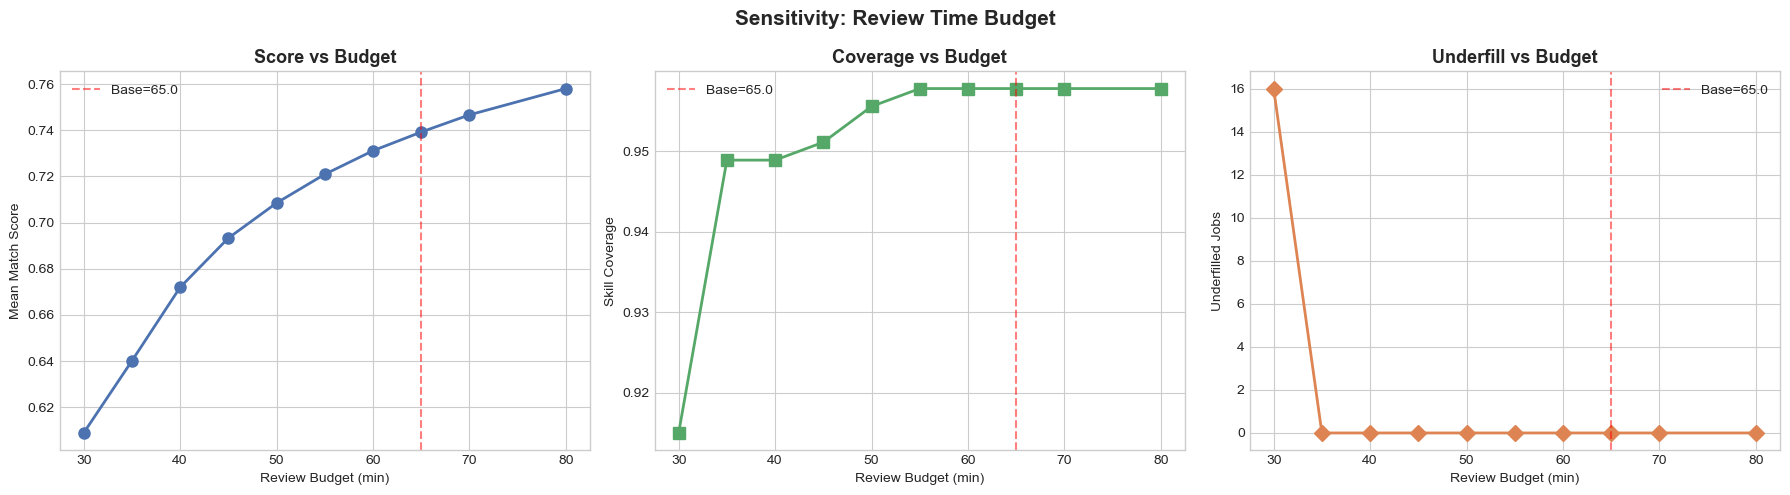

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(budget_df["budget"], budget_df["mean_score"], "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].axvline(BASE_BUDGET, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_BUDGET}")
axes[0].set_xlabel("Review Budget (min)"); axes[0].set_ylabel("Mean Match Score")
axes[0].set_title("Score vs Budget", fontsize=13, fontweight="bold"); axes[0].legend()

axes[1].plot(budget_df["budget"], budget_df["mean_coverage"], "s-", color="#55A868", linewidth=2, markersize=8)
axes[1].axvline(BASE_BUDGET, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_BUDGET}")
axes[1].set_xlabel("Review Budget (min)"); axes[1].set_ylabel("Skill Coverage")
axes[1].set_title("Coverage vs Budget", fontsize=13, fontweight="bold"); axes[1].legend()

axes[2].plot(budget_df["budget"], budget_df["underfilled"], "D-", color="#DD8452", linewidth=2, markersize=8)
axes[2].axvline(BASE_BUDGET, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_BUDGET}")
axes[2].set_xlabel("Review Budget (min)"); axes[2].set_ylabel("Underfilled Jobs")
axes[2].set_title("Underfill vs Budget", fontsize=13, fontweight="bold"); axes[2].legend()

fig.suptitle("Sensitivity: Review Time Budget", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "01_sensitivity_budget.png", dpi=150, bbox_inches="tight"); plt.show()

### 3.3 Experiment 2: Shortlist Size (k)

*"What happens when recruiters want bigger or smaller shortlists?"*

In [14]:
print("Sweeping shortlist size …")
k_values = [3, 4, 5, 6, 7, 8]
k_df = sensitivity_sweep("k", k_values, BASE_KWARGS, BEST_CONFIG)
display(k_df[["k", "mean_score", "mean_coverage", "underfilled", "total_selected", "novelty"]])

Sweeping shortlist size …
  k=3 … score=0.793, coverage=0.958, underfilled=0
  k=4 … score=0.769, coverage=0.958, underfilled=0
  k=5 … score=0.739, coverage=0.958, underfilled=0
  k=6 … score=0.707, coverage=0.958, underfilled=0
  k=7 … score=0.669, coverage=0.958, underfilled=0
  k=8 … score=0.630, coverage=0.951, underfilled=9


,k,mean_score,mean_coverage,underfilled,total_selected,novelty
0,3,0.7933,0.9578,0,270,0.6593
1,4,0.7687,0.9578,0,360,0.6306
2,5,0.7392,0.9578,0,450,0.6022
3,6,0.7072,0.9578,0,540,0.5741
4,7,0.6692,0.9578,0,630,0.5476
5,8,0.6302,0.9511,9,705,0.5106


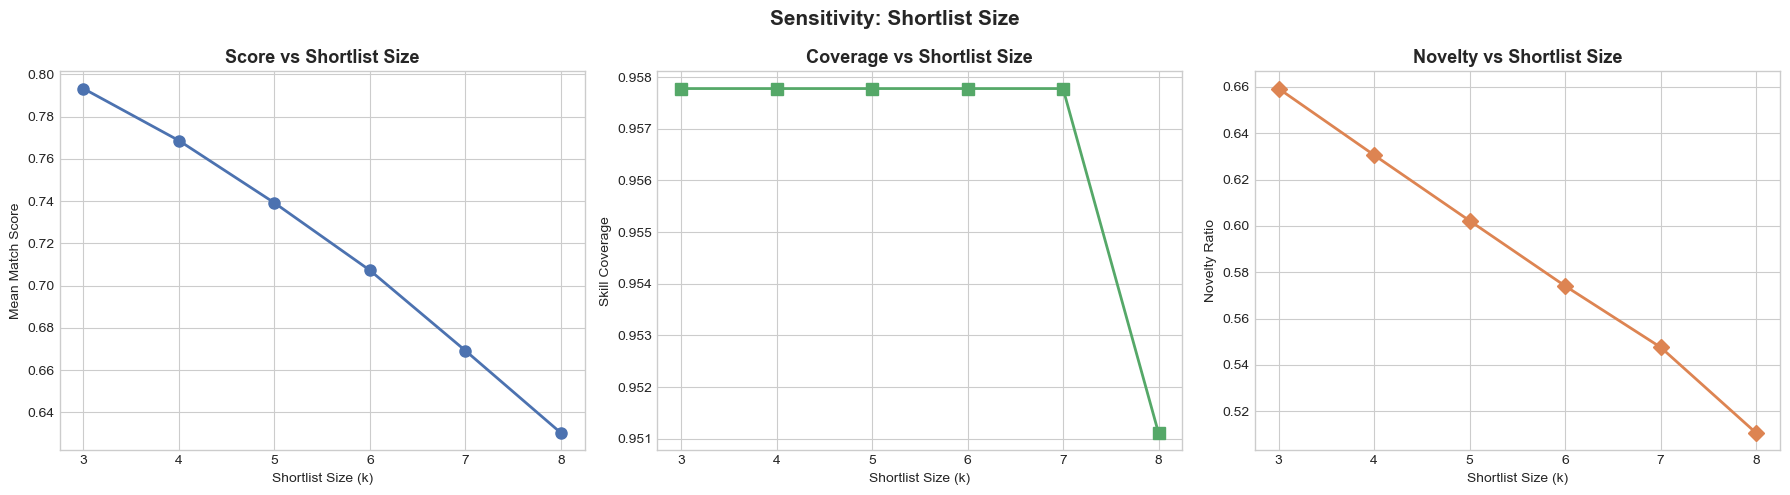

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_df["k"], k_df["mean_score"], "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].set_xlabel("Shortlist Size (k)"); axes[0].set_ylabel("Mean Match Score")
axes[0].set_title("Score vs Shortlist Size", fontsize=13, fontweight="bold")

axes[1].plot(k_df["k"], k_df["mean_coverage"], "s-", color="#55A868", linewidth=2, markersize=8)
axes[1].set_xlabel("Shortlist Size (k)"); axes[1].set_ylabel("Skill Coverage")
axes[1].set_title("Coverage vs Shortlist Size", fontsize=13, fontweight="bold")

axes[2].plot(k_df["k"], k_df["novelty"], "D-", color="#DD8452", linewidth=2, markersize=8)
axes[2].set_xlabel("Shortlist Size (k)"); axes[2].set_ylabel("Novelty Ratio")
axes[2].set_title("Novelty vs Shortlist Size", fontsize=13, fontweight="bold")

fig.suptitle("Sensitivity: Shortlist Size", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "02_sensitivity_k.png", dpi=150, bbox_inches="tight"); plt.show()

### 3.4 Experiment 3: Candidate Exposure Cap

*"Should candidates be allowed on more shortlists? What's the trade-off?"*

In [17]:
print("Sweeping exposure cap …")
exposure_values = [1, 2, 3, 4, 5]
exp_df = sensitivity_sweep("max_exposure", exposure_values, BASE_KWARGS, BEST_CONFIG)
display(exp_df[["max_exposure", "mean_score", "mean_coverage", "underfilled", "novelty"]])

Sweeping exposure cap …
  max_exposure=1 … score=0.688, coverage=0.956, underfilled=0
  max_exposure=2 … score=0.739, coverage=0.958, underfilled=0
  max_exposure=3 … score=0.751, coverage=0.958, underfilled=0
  max_exposure=4 … score=0.756, coverage=0.958, underfilled=0
  max_exposure=5 … score=0.758, coverage=0.958, underfilled=0


,max_exposure,mean_score,mean_coverage,underfilled,novelty
0,1,0.6879,0.9556,0,1.0000
1,2,0.7392,0.9578,0,0.6022
2,3,0.7514,0.9578,0,0.4978
3,4,0.7561,0.9578,0,0.4489
4,5,0.7579,0.9578,0,0.4333


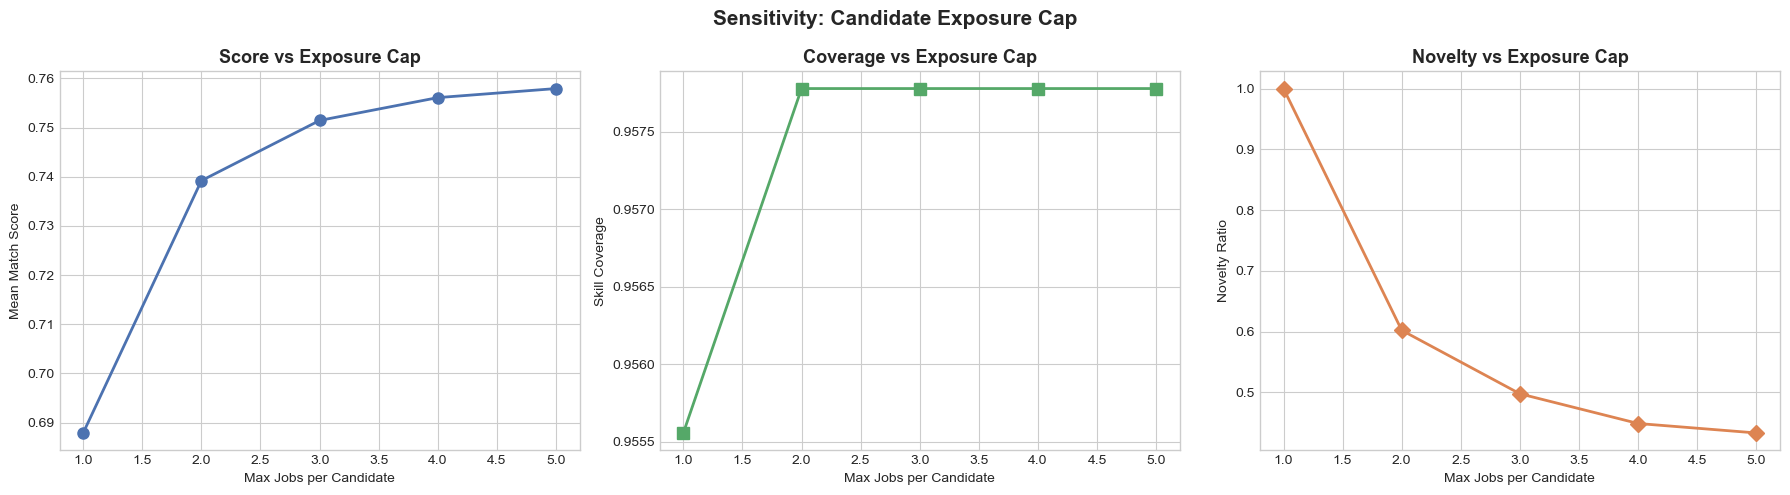

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(exp_df["max_exposure"], exp_df["mean_score"], "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].set_xlabel("Max Jobs per Candidate"); axes[0].set_ylabel("Mean Match Score")
axes[0].set_title("Score vs Exposure Cap", fontsize=13, fontweight="bold")

axes[1].plot(exp_df["max_exposure"], exp_df["mean_coverage"], "s-", color="#55A868", linewidth=2, markersize=8)
axes[1].set_xlabel("Max Jobs per Candidate"); axes[1].set_ylabel("Skill Coverage")
axes[1].set_title("Coverage vs Exposure Cap", fontsize=13, fontweight="bold")

axes[2].plot(exp_df["max_exposure"], exp_df["novelty"], "D-", color="#DD8452", linewidth=2, markersize=8)
axes[2].set_xlabel("Max Jobs per Candidate"); axes[2].set_ylabel("Novelty Ratio")
axes[2].set_title("Novelty vs Exposure Cap", fontsize=13, fontweight="bold")

fig.suptitle("Sensitivity: Candidate Exposure Cap", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "03_sensitivity_exposure.png", dpi=150, bbox_inches="tight"); plt.show()

### 3.5 Experiment 4: Quality Floor

*"How strict should the minimum match quality requirement be?"*

In [20]:
print("Sweeping quality floor …")
floor_values = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
floor_df = sensitivity_sweep("floor", floor_values, BASE_KWARGS, BEST_CONFIG)
display(floor_df[["floor", "mean_score", "mean_coverage", "underfilled", "novelty"]])

Sweeping quality floor …
  floor=0.2 … score=0.739, coverage=0.958, underfilled=0
  floor=0.25 … score=0.739, coverage=0.958, underfilled=0
  floor=0.3 … score=0.739, coverage=0.958, underfilled=0
  floor=0.35 … score=0.739, coverage=0.958, underfilled=0
  floor=0.4 … score=0.739, coverage=0.958, underfilled=0
  floor=0.45 … score=0.739, coverage=0.958, underfilled=0
  floor=0.5 … score=0.739, coverage=0.958, underfilled=0
  floor=0.55 … score=0.739, coverage=0.958, underfilled=0
  floor=0.6 … score=0.739, coverage=0.958, underfilled=0


,floor,mean_score,mean_coverage,underfilled,novelty
0,0.2000,0.7391,0.9578,0,0.6044
1,0.2500,0.7392,0.9578,0,0.6133
2,0.3000,0.7393,0.9578,0,0.6044
3,0.3500,0.7393,0.9578,0,0.6111
4,0.4000,0.7392,0.9578,0,0.6022
5,0.4500,0.7392,0.9578,0,0.6178
6,0.5000,0.7392,0.9578,0,0.6111
7,0.5500,0.7391,0.9578,0,0.6044
8,0.6000,0.7392,0.9578,0,0.6111


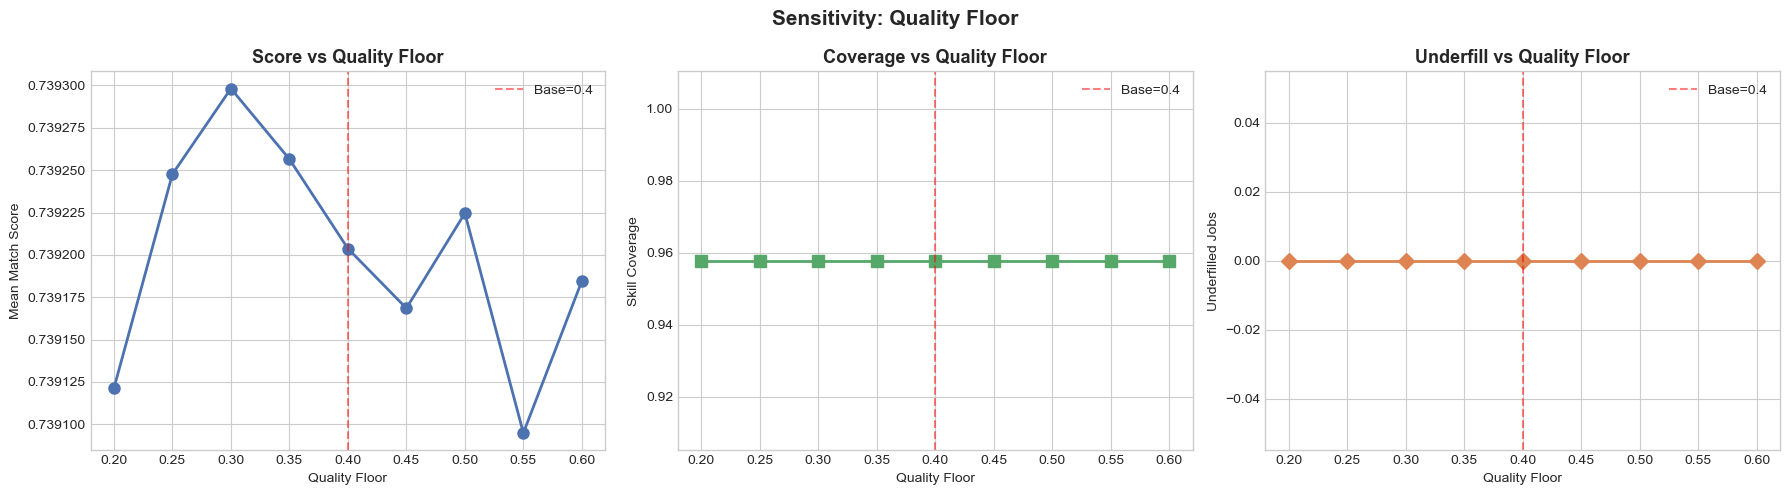

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(floor_df["floor"], floor_df["mean_score"], "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].axvline(BASE_FLOOR, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_FLOOR}")
axes[0].set_xlabel("Quality Floor"); axes[0].set_ylabel("Mean Match Score")
axes[0].set_title("Score vs Quality Floor", fontsize=13, fontweight="bold"); axes[0].legend()

axes[1].plot(floor_df["floor"], floor_df["mean_coverage"], "s-", color="#55A868", linewidth=2, markersize=8)
axes[1].axvline(BASE_FLOOR, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_FLOOR}")
axes[1].set_xlabel("Quality Floor"); axes[1].set_ylabel("Skill Coverage")
axes[1].set_title("Coverage vs Quality Floor", fontsize=13, fontweight="bold"); axes[1].legend()

axes[2].plot(floor_df["floor"], floor_df["underfilled"], "D-", color="#DD8452", linewidth=2, markersize=8)
axes[2].axvline(BASE_FLOOR, color="red", linestyle="--", alpha=0.5, label=f"Base={BASE_FLOOR}")
axes[2].set_xlabel("Quality Floor"); axes[2].set_ylabel("Underfilled Jobs")
axes[2].set_title("Underfill vs Quality Floor", fontsize=13, fontweight="bold"); axes[2].legend()

fig.suptitle("Sensitivity: Quality Floor", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "04_sensitivity_floor.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Summary Dashboard

A single 4×3 figure showing all sensitivity experiments together.

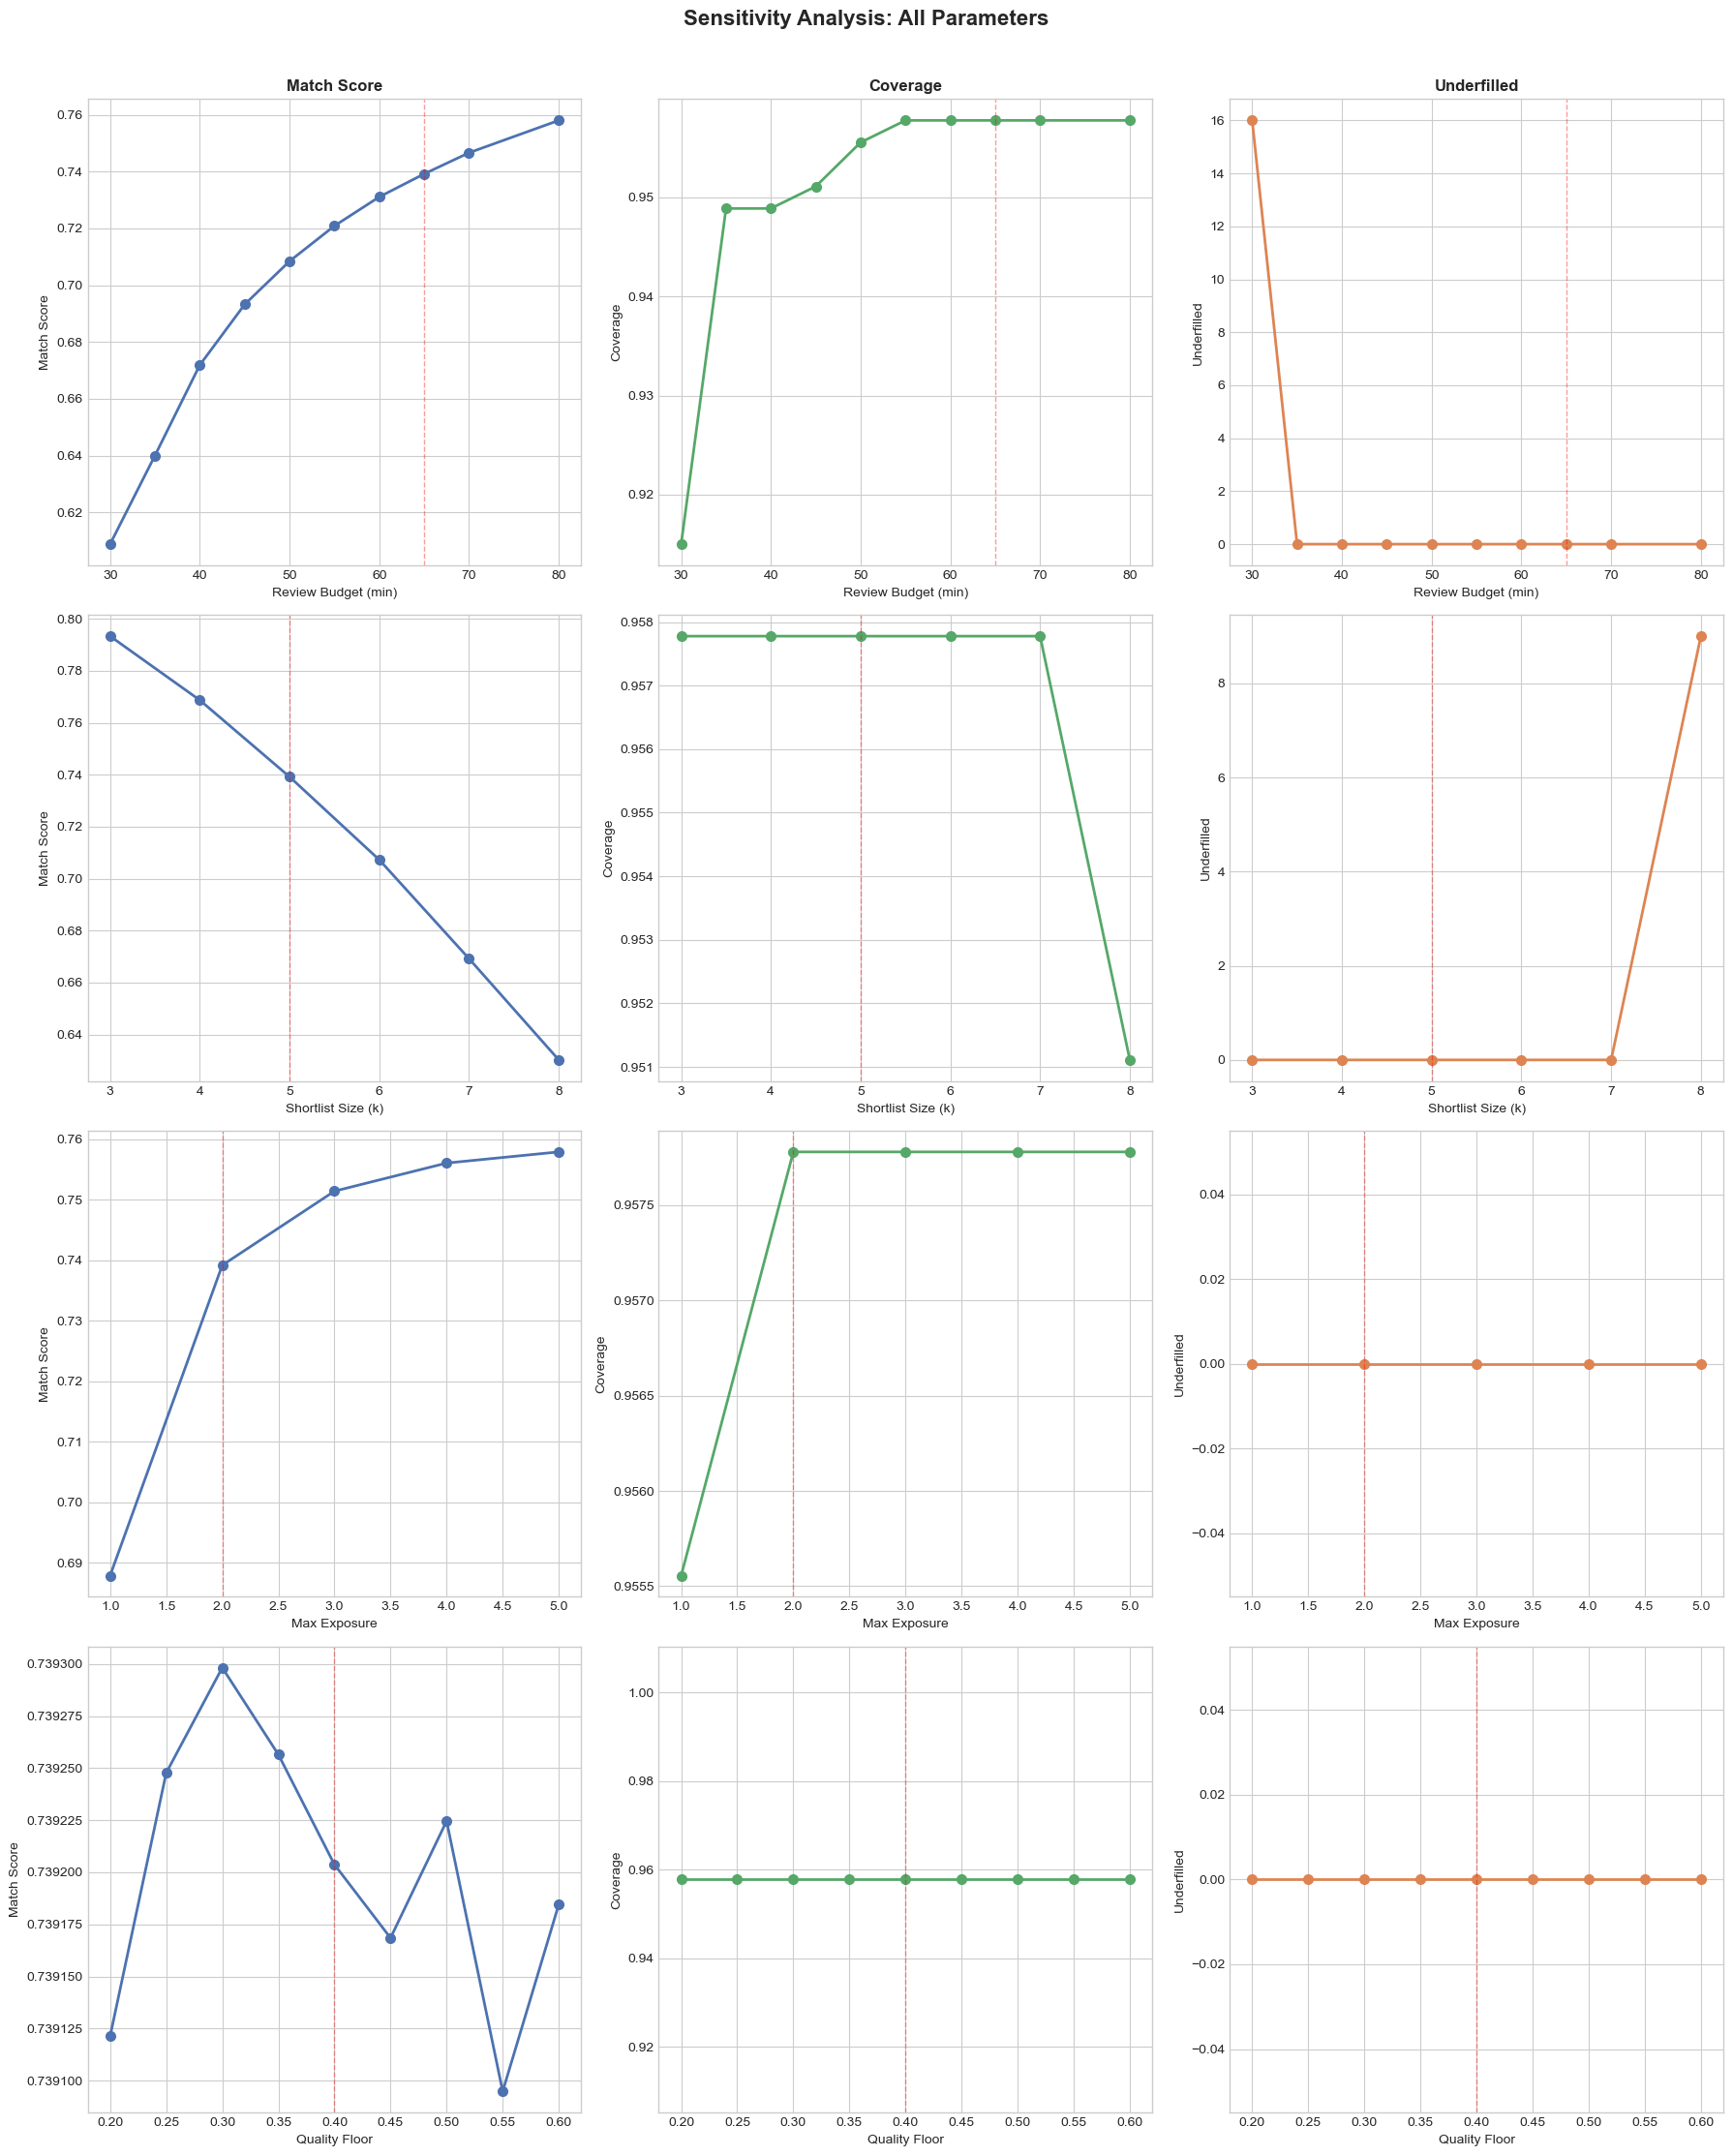

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

datasets = [
    (budget_df, "budget", "Review Budget (min)", BASE_BUDGET),
    (k_df, "k", "Shortlist Size (k)", 5),
    (exp_df, "max_exposure", "Max Exposure", 2),
    (floor_df, "floor", "Quality Floor", BASE_FLOOR),
]
metrics = [("mean_score", "Match Score"), ("mean_coverage", "Coverage"), ("underfilled", "Underfilled")]
colours = ["#4C72B0", "#55A868", "#DD8452"]

for row, (df, param, xlabel, base) in enumerate(datasets):
    for col, ((metric, ylabel), colour) in enumerate(zip(metrics, colours)):
        ax = axes[row, col]
        ax.plot(df[param], df[metric], "o-", color=colour, linewidth=2, markersize=7)
        if base is not None:
            ax.axvline(base, color="red", linestyle="--", alpha=0.4, linewidth=1)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        if row == 0: ax.set_title(ylabel, fontsize=12, fontweight="bold")

fig.suptitle("Sensitivity Analysis: All Parameters", fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig(OUT_DIR / "05_sensitivity_dashboard.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Key Findings

### Budget Sensitivity
- **Tightest constraint**: below ~40 min, the model is forced to pick short resumes over good ones, causing score and coverage to drop sharply
- **Diminishing returns**: above ~65 min, additional budget barely improves results — the model has already found the best candidates
- **Recommended**: 55–65 min provides the best quality-per-minute trade-off

### Shortlist Size
- **Coverage improves** with larger shortlists (more candidates = more skill diversity)
- **Score decreases** as the model must dig deeper into the candidate pool
- **Novelty drops** since more candidates are needed total, increasing reuse pressure
- k = 5 balances these trade-offs well

### Exposure Cap
- **cap = 1** means every candidate appears on at most one shortlist — high novelty but the model may struggle to fill all shortlists
- **cap ≥ 3** provides diminishing returns on score/coverage while novelty degrades
- cap = 2 is the sweet spot: enough flexibility for the optimiser without excessive reuse

### Quality Floor
- **Low floor** (< 0.30): effectively inactive — the optimiser already prefers good candidates
- **High floor** (> 0.50): forces the model to leave jobs underfilled when the candidate pool is thin for certain roles
- 0.35–0.45 ensures a baseline quality without over-constraining

## 6. Save Results

In [26]:
budget_df.to_csv(OUT_DIR / "sensitivity_budget.csv", index=False)
k_df.to_csv(OUT_DIR / "sensitivity_k.csv", index=False)
exp_df.to_csv(OUT_DIR / "sensitivity_exposure.csv", index=False)
floor_df.to_csv(OUT_DIR / "sensitivity_floor.csv", index=False)

print("Saved:")
for f in sorted(OUT_DIR.glob("*")):
    print(f"  {f.name}")

Saved:
  01_extraction_coverage.png
  01_method_comparison.png
  01_sensitivity_budget.png
  02_job_title_distribution.png
  02_sensitivity_k.png
  02_sweep_results.png
  03_sensitivity_exposure.png
  03_word_count_distributions.png
  04_sensitivity_floor.png
  04_skills_analysis.png
  05_experience_education.png
  05_sensitivity_dashboard.png
  06_redundancy_sweep.png
  07_redundancy_clusters.png
  best_config.json
  greedy_selected.csv
  method_comparison.csv
  milp_best_selected.csv
  scoreonly_selected.csv
  sensitivity_budget.csv
  sensitivity_exposure.csv
  sensitivity_floor.csv
  sensitivity_k.csv
  sweep_results.csv
